# CS 4391/5391 – Reinforcement Learning  
## Homework 3 Notebook Submission

**Name:**
Chepuri Madhukanthi - R11971602

*   Chepuri Madhukanthi - R11971602
*   Bhanu Sankar Ravi - R11971600
*   Mahindra Alla - R11975196  

**Submission :** Team 10

### Team contribution statement
This was completed individually.

### How I set up the environment
For this homework I used the **5 × 10 grid** suggested in assignment HW3. I kept the same basic motion model from HW2, where the intended action happens with probability **0.7** and each of the other three actions happens with probability **0.1**. The normal step reward is **-1**, the goal reward is **0**, and the new part mentioned in HW3 is the **cliff penalty of -100 with teleportation back to the start**.  

I also kept the start and goal at opposite corners of the grid, with the cliff placed as a block of 3 cells on the top boundary. So the notebook follows the HW3 instructions, while still being similar to HW2.  




## 1. Setup code

In this first code cell, I define the grid, the stochastic movement model, the `step(state, action)` function for the cliff environment, and the helper functions for rollouts, Q-learning, SARSA, and plotting. I also run the experiments once here so that the rest of the tasks can focus on the required on the outputs.



In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# just setting some default plot sizes so the figures are easier to read
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

# grid setup
ROWS, COLS = 5, 10
START = (4, 0)
GOAL = (0, 9)
CLIFF = {(0, 6), (0, 7), (0, 8)}
FENCES = set()

# actions: up, down, left, right
ACTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)]
ACTION_NAMES = ["Up", "Down", "Left", "Right"]
ACTION_SYMBOLS = ["↑", "↓", "←", "→"]

# same base numbers from HW2, then I add the cliff penalty for HW3
INTENDED_PROB = 0.7
OTHER_PROB = 0.1
STEP_REWARD = -1.0
GOAL_REWARD = 0.0
CLIFF_REWARD = -100.0
GAMMA = 0.975

# fixed seeds so the notebook is reproducible
TASK1_RANDOM_POLICY_SEED = 123
RUN_SEEDS = [11, 22, 33, 44, 55]

states = [(r, c) for r in range(ROWS) for c in range(COLS)]
nonterminal_states = [s for s in states if s != GOAL and s not in FENCES]

# where each action would go if there was no randomness
move = np.zeros((ROWS, COLS, 4, 2), dtype=int)
for r in range(ROWS):
    for c in range(COLS):
        for a, (dr, dc) in enumerate(ACTIONS):
            nr, nc = r + dr, c + dc
            if not (0 <= nr < ROWS and 0 <= nc < COLS) or (nr, nc) in FENCES:
                nr, nc = r, c
            move[r, c, a] = (nr, nc)

# probability of actual action given intended action
action_prob = np.full((4, 4), OTHER_PROB, dtype=float)
for a in range(4):
    action_prob[a, a] = INTENDED_PROB


def sample_actual_action(intended_a, rng):
    # because the environment is stochastic, the action taken is sampled
    x = rng.random()
    total = 0.0
    for aa in range(4):
        total += action_prob[intended_a, aa]
        if x <= total:
            return aa
    return 3


# no-cliff model from HW2 (used to get the old optimal policy)
orig_transitions = {}
for s in states:
    for intended_a in range(4):
        if s == GOAL:
            orig_transitions[(s, intended_a)] = [(1.0, GOAL, GOAL_REWARD)]
        else:
            r, c = s
            temp = {}
            for aa, p in enumerate(action_prob[intended_a]):
                nr, nc = move[r, c, aa]
                ns = (int(nr), int(nc))
                temp[ns] = temp.get(ns, 0.0) + p
            orig_transitions[(s, intended_a)] = [
                (p, ns, GOAL_REWARD if ns == GOAL else STEP_REWARD)
                for ns, p in temp.items()
            ]


def evaluate_policy(policy, theta=1e-10):
  # standard iterative policy evaluation
    V = np.zeros((ROWS, COLS), dtype=float)
    while True:
        delta = 0.0
        newV = V.copy()
        for s in nonterminal_states:
            a = policy[s]
            val = 0.0
            for p, ns, r in orig_transitions[(s, a)]:
                val += p * (r + GAMMA * V[ns])
            newV[s] = val
            delta = max(delta, abs(val - V[s]))
        newV[GOAL] = 0.0
        V = newV
        if delta < theta:
            break
    return V

# tie-breaking order for argmax
# if values are equal, I prefer right first, then up, then left, then down
ACTION_PREFERENCE = [3, 0, 2, 1]  # right, up, left, down


def argmax_with_preference(q):
  # pick the best action, but use the preference order above for ties
    best = np.max(q)
    for a in ACTION_PREFERENCE:
        if q[a] >= best - 1e-12:
            return a
    return int(np.argmax(q))


def policy_iteration():
  # start with a simple initial policy that always tries to move right
    policy = np.zeros((ROWS, COLS), dtype=int)
    for s in nonterminal_states:
        policy[s] = 3

    stable = False
    n_iter = 0
    while not stable and n_iter < 100:
        n_iter += 1
        V = evaluate_policy(policy)
        stable = True
        for s in nonterminal_states:
            q = np.zeros(4, dtype=float)
            for a in range(4):
                q[a] = sum(p * (r + GAMMA * V[ns]) for p, ns, r in orig_transitions[(s, a)])
            best_a = argmax_with_preference(q)
            if best_a != policy[s]:
                stable = False
                policy[s] = best_a
    return policy, V, n_iter


# actual HW3 cliff step function
def step_cliff(state, intended_a, rng):
    if state == GOAL:
        return GOAL, GOAL_REWARD
# sample the actual action because the world is stochastic
    actual_a = sample_actual_action(intended_a, rng)
    nr, nc = move[state[0], state[1], actual_a]
    ns = (int(nr), int(nc))

    if ns in CLIFF:
        return START, CLIFF_REWARD
    if ns == GOAL:
        return GOAL, GOAL_REWARD
    return ns, STEP_REWARD


def rollout(policy, start_state, seed=0, max_steps=200):
  # simulate one trajectory following the given policy
    rng = np.random.default_rng(seed)
    s = start_state
    traj = [s]
    total_reward = 0.0
    cliff_hits = 0

    for _ in range(max_steps):
        if s == GOAL:
            break
        a = policy[s]
        ns, r = step_cliff(s, a, rng)
        total_reward += r
        if r == CLIFF_REWARD:
            cliff_hits += 1
        s = ns
        traj.append(s)
        if s == GOAL:
            break

    return {
        "trajectory": traj,
        "return": total_reward,
        "cliff_hits": cliff_hits,
        "reached_goal": s == GOAL,
        "length": len(traj) - 1,
    }


def summarize_rollouts(results):
  # summarize a group of rollout results into easy-to-read metrics
    return {
        "mean_return": float(np.mean([x["return"] for x in results])),
        "std_return": float(np.std([x["return"] for x in results])),
        "mean_length": float(np.mean([x["length"] for x in results])),
        "successes": int(sum(x["reached_goal"] for x in results)),
        "cliff_hits": int(sum(x["cliff_hits"] for x in results)),
    }


def epsilon_greedy(Q, s, rng, epsilon=0.1):
  # epsilon-greedy action selection:
  # explore with probability epsilon, otherwise exploit the best action
    if rng.random() < epsilon:
        return int(rng.integers(0, 4))
    q = Q[s]
    best = np.flatnonzero(np.isclose(q, np.max(q)))
    return int(best[rng.integers(0, len(best))])


def q_learning(num_episodes=800, alpha=0.2, epsilon=0.1, max_steps=200, seed=0):
  # off-policy TD control using Q-learning
    Q = np.zeros((ROWS, COLS, 4), dtype=float)
    returns = np.zeros(num_episodes, dtype=float)
    rng = np.random.default_rng(seed)

    for ep in range(num_episodes):
        s = START
        total = 0.0
        for _ in range(max_steps):
            if s == GOAL:
                break
            a = epsilon_greedy(Q, s, rng, epsilon)
            ns, r = step_cliff(s, a, rng)
            total += r
            Q[s][a] += alpha * (r + GAMMA * np.max(Q[ns]) - Q[s][a])
            s = ns
            if s == GOAL:
                break
        returns[ep] = total

    return Q, returns


def sarsa(num_episodes=800, alpha=0.2, epsilon=0.1, max_steps=200, seed=0):
  # on-policy TD control using SARSA
    Q = np.zeros((ROWS, COLS, 4), dtype=float)
    returns = np.zeros(num_episodes, dtype=float)
    rng = np.random.default_rng(seed)

    for ep in range(num_episodes):
        s = START
        a = epsilon_greedy(Q, s, rng, epsilon)
        total = 0.0
        for _ in range(max_steps):
            ns, r = step_cliff(s, a, rng)
            total += r
            if ns == GOAL:
                Q[s][a] += alpha * (r - Q[s][a])
                break
            na = epsilon_greedy(Q, ns, rng, epsilon)
            Q[s][a] += alpha * (r + GAMMA * Q[ns][na] - Q[s][a])
            s, a = ns, na
        returns[ep] = total

    return Q, returns


def greedy_policy_and_value(Q):
  # extract the greedy policy and the corresponding state values from Q
    policy = np.full((ROWS, COLS), -1, dtype=int)
    V = np.full((ROWS, COLS), np.nan, dtype=float)
    for s in nonterminal_states:
        policy[s] = int(np.argmax(Q[s]))
        V[s] = float(np.max(Q[s]))
    V[GOAL] = 0.0
    return policy, V


def evaluate_greedy_policy(policy, episodes=200, max_steps=200, seed=999):
  # evaluate the final greedy policy over many episodes
    rng = np.random.default_rng(seed)
    returns, cliff_hits, lengths = [], [], []
    successes = 0

    for _ in range(episodes):
        s = START
        total = 0.0
        cliffs = 0
        for t in range(max_steps):
            if s == GOAL:
                break
            a = policy[s]
            ns, r = step_cliff(s, a, rng)
            total += r
            if r == CLIFF_REWARD:
                cliffs += 1
            s = ns
            if s == GOAL:
                break
        returns.append(total)
        cliff_hits.append(cliffs)
        lengths.append(t + 1)
        successes += int(s == GOAL)

    return {
        "mean_return": float(np.mean(returns)),
        "std_return": float(np.std(returns)),
        "mean_cliff_hits": float(np.mean(cliff_hits)),
        "success_rate": successes / episodes,
        "mean_length": float(np.mean(lengths)),
    }


def draw_grid(ax, title="", show_labels=True):
  # draw the cliff world grid and mark start, goal, and cliff cells
    ax.set_xlim(-0.5, COLS - 0.5)
    ax.set_ylim(ROWS - 0.5, -0.5)
    ax.set_xticks(range(COLS))
    ax.set_yticks(range(ROWS))
    ax.set_xticks(np.arange(-0.5, COLS, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, ROWS, 1), minor=True)
    ax.grid(which="minor", color="black", linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.set_aspect("equal")
    ax.set_title(title)

    for r in range(ROWS):
        for c in range(COLS):
            if (r, c) in CLIFF:
                ax.add_patch(Rectangle((c - 0.5, r - 0.5), 1, 1, color="#d62728", alpha=0.25))
                if show_labels:
                    ax.text(c, r, "C", ha="center", va="center", fontsize=12, weight="bold")
            elif (r, c) == START:
                ax.add_patch(Rectangle((c - 0.5, r - 0.5), 1, 1, color="#2ca02c", alpha=0.18))
                if show_labels:
                    ax.text(c, r, "S", ha="center", va="center", fontsize=12, weight="bold")
            elif (r, c) == GOAL:
                ax.add_patch(Rectangle((c - 0.5, r - 0.5), 1, 1, color="#1f77b4", alpha=0.18))
                if show_labels:
                    ax.text(c, r, "G", ha="center", va="center", fontsize=12, weight="bold")


def plot_trajectories(ax, trajectories, title):
  # plot one or more trajectories on the grid
    draw_grid(ax, title)
    for i, item in enumerate(trajectories):
        traj = item["trajectory"]
        xs = [s[1] for s in traj]
        ys = [s[0] for s in traj]
        ax.plot(xs, ys, marker="o", markersize=2.5, linewidth=1.2, alpha=0.85, label=f"T{i+1}")
        ax.scatter(xs[0], ys[0], s=28, marker="s")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=8)


def plot_value_policy(ax, V, policy, title):
  # show the value function as colors and the policy as arrows
    im = ax.imshow(np.array(V, dtype=float), cmap="viridis")
    draw_grid(ax, title, show_labels=False)

    for r in range(ROWS):
        for c in range(COLS):
            if (r, c) in CLIFF:
                ax.text(c, r, "C", ha="center", va="center", fontsize=11, weight="bold", color="white")
            elif (r, c) == START:
                ax.text(c, r, "S", ha="center", va="center", fontsize=11, weight="bold", color="white")
            elif (r, c) == GOAL:
                ax.text(c, r, "G", ha="center", va="center", fontsize=11, weight="bold", color="white")
            else:
                ax.text(c, r, f"{V[r, c]:.1f}", ha="center", va="center", fontsize=7, color="white")

    for r in range(ROWS):
        for c in range(COLS):
            s = (r, c)
            if s == GOAL or s in CLIFF:
                continue
            a = policy[s]
            dr, dc = ACTIONS[a]
            ax.arrow(
                c,
                r,
                0.22 * dc,
                0.22 * dr,
                head_width=0.12,
                head_length=0.10,
                fc="white",
                ec="white",
                linewidth=1.2,
                length_includes_head=True,
            )
    return im


#results

# first, solve the old no-cliff HW2 problem using policy iteration
optimal_policy_hw2, V_no_cliff, n_pi_iter = policy_iteration()

# different starting states for task 1 rollouts
initial_states = [(4, 0), (4, 2), (4, 5), (3, 0), (3, 4), (3, 7), (2, 1), (2, 5), (1, 0), (1, 4)]

# create one random policy for comparison
rng = np.random.default_rng(TASK1_RANDOM_POLICY_SEED)
random_policy = np.zeros((ROWS, COLS), dtype=int)
for s in nonterminal_states:
    random_policy[s] = rng.integers(0, 4)

# rollout both the random policy and the HW2 optimal policy in the cliff environment
random_results = [rollout(random_policy, s, seed=100 + i) for i, s in enumerate(initial_states)]
hw2_policy_results = [rollout(optimal_policy_hw2, s, seed=100 + i) for i, s in enumerate(initial_states)]

task1_random_summary = summarize_rollouts(random_results)
task1_hw2_summary = summarize_rollouts(hw2_policy_results)

# table that compares rollout results for each initial state
task1_table = pd.DataFrame({
    "Initial State": initial_states,
    "Random Return": [x["return"] for x in random_results],
    "Random Length": [x["length"] for x in random_results],
    "Random Goal?": [x["reached_goal"] for x in random_results],
    "Random Cliff Hits": [x["cliff_hits"] for x in random_results],
    "HW2-Optimal Return": [x["return"] for x in hw2_policy_results],
    "HW2-Optimal Length": [x["length"] for x in hw2_policy_results],
    "HW2-Optimal Goal?": [x["reached_goal"] for x in hw2_policy_results],
    "HW2-Optimal Cliff Hits": [x["cliff_hits"] for x in hw2_policy_results],
})

# store multiple runs for Q-learning and SARSA
q_returns = []
sarsa_returns = []
q_models = []
sarsa_models = []

# run both algorithms with several random seeds
for seed in RUN_SEEDS:
    Q, q_ret = q_learning(seed=seed)
    S, s_ret = sarsa(seed=seed)
    q_returns.append(q_ret)
    sarsa_returns.append(s_ret)
    q_models.append(Q)
    sarsa_models.append(S)

# stack all returns so I can compute average learning curves
q_returns = np.vstack(q_returns)
sarsa_returns = np.vstack(sarsa_returns)

q_avg = q_returns.mean(axis=0)
q_std = q_returns.std(axis=0)
s_avg = sarsa_returns.mean(axis=0)
s_std = sarsa_returns.std(axis=0)

# average the learned Q-tables across runs
Q_mean = np.mean(np.stack(q_models, axis=0), axis=0)
S_mean = np.mean(np.stack(sarsa_models, axis=0), axis=0)

mean_q_policy, mean_q_value = greedy_policy_and_value(Q_mean)
mean_sarsa_policy, mean_sarsa_value = greedy_policy_and_value(S_mean)

# evaluate the final greedy policies
q_eval = evaluate_greedy_policy(mean_q_policy)
s_eval = evaluate_greedy_policy(mean_sarsa_policy)

print("Environment ready.")
print(f"Policy iteration on the no-cliff HW2 model converged in {n_pi_iter} improvement steps.")
print(f"Task 1 random policy success count: {task1_random_summary['successes']}/10")
print(f"Task 1 HW2-style policy success count: {task1_hw2_summary['successes']}/10")


Environment ready.
Policy iteration on the no-cliff HW2 model converged in 4 improvement steps.
Task 1 random policy success count: 2/10
Task 1 HW2-style policy success count: 10/10


## Task 1 – Cliff-walking environment

The first requirement was to turn the gridworld into a sample-based environment. So instead of using only transition tables, I now use a **step function** that samples the actual move and returns the next state and reward.

For this task I compare two behaviors:

1. **A random policy**, using 10 different initial states.
2. **The HW2 optimal policy**, again from 10 different initial states.

This is useful because it shows how much the new cliff changes behavior. A policy that looked good before the cliff was added may still reach the goal, but now it also has to deal with a very costly risky region.



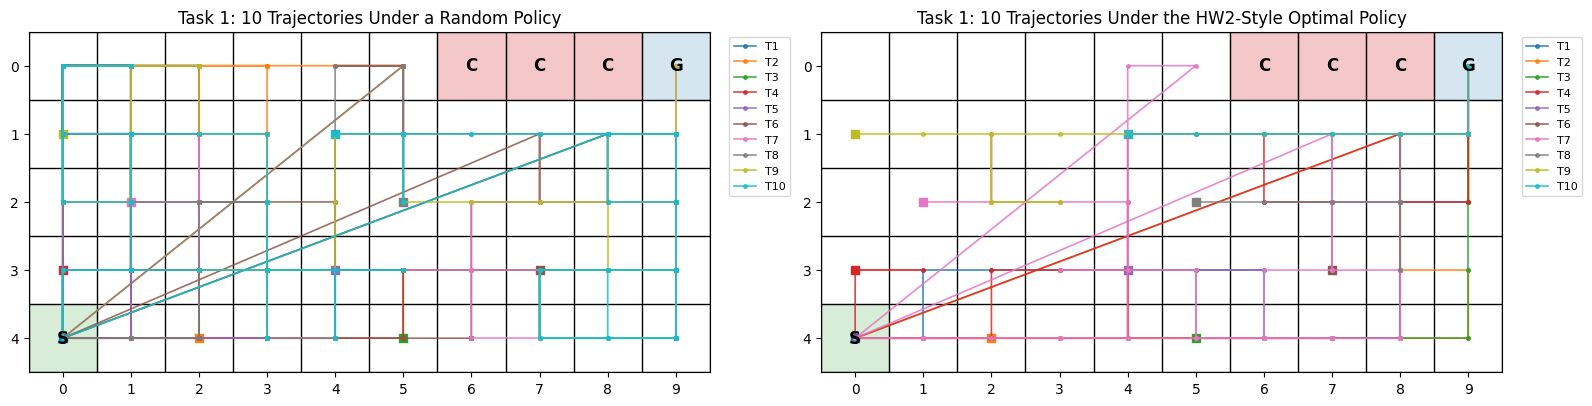

Random policy summary:
{'mean_return': -251.9, 'std_return': 74.30269174128216, 'mean_length': 192.7, 'successes': 2, 'cliff_hits': 6}

HW2-style optimal policy summary:
{'mean_return': -61.1, 'std_return': 80.0780244511564, 'mean_length': 22.5, 'successes': 10, 'cliff_hits': 4}


,Initial State,Random Return,Random Length,Random Goal?,Random Cliff Hits,HW2-Optimal Return,HW2-Optimal Length,HW2-Optimal Goal?,HW2-Optimal Cliff Hits
0,"(4, 0)",-200.0,200,False,0,-22.0,23,True,0
1,"(4, 2)",-299.0,200,False,1,-134.0,36,True,1
2,"(4, 5)",-299.0,200,False,1,-17.0,18,True,0
3,"(3, 0)",-200.0,200,False,0,-142.0,44,True,1
4,"(3, 4)",-200.0,200,False,0,-17.0,18,True,0
5,"(3, 7)",-398.0,200,False,2,-4.0,5,True,0
6,"(2, 1)",-141.0,142,True,0,-249.0,52,True,2
7,"(2, 5)",-299.0,200,False,1,-8.0,9,True,0
8,"(1, 0)",-184.0,185,True,0,-13.0,14,True,0
9,"(1, 4)",-299.0,200,False,1,-5.0,6,True,0


In [4]:

# Environment and trajectory visualization for Task 1
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_trajectories(axes[0], random_results, "Task 1: 10 Trajectories Under a Random Policy")
plot_trajectories(axes[1], hw2_policy_results, "Task 1: 10 Trajectories Under the HW2-Style Optimal Policy")

plt.tight_layout()
plt.show()

print("Random policy summary:")
print(task1_random_summary)
print("\nHW2-style optimal policy summary:")
print(task1_hw2_summary)

task1_table


**The figure above:** the random-policy trajectories spread out more and bounce around because of both bad action choices and the 0.7/0.1 stochastic movement. The HW2-style policy trajectories are much more directed toward the goal, but a few of them still get too close to the cliff and pay the reset penalty.


### Task 1 Discussion

The difference between the two policies is easy to see in both the trajectories and the summary table. The random policy wanders a lot, sometimes gets pushed around by the stochastic transitions, and falls into the cliff several times. Because of the reset to the start and the `-100` penalty, even a few cliff hits make the total return much worse. In my run, the random policy reached the goal only **2 out of 10** times and had **6 cliff hits**, so its average return became very negative.

The HW2-style policy does much better even though it was not originally designed with the cliff in mind. It still reaches the goal **10 out of 10** times and its average path length is much shorter. At the same time, it is not completely safe in the new environment, because I still saw **3 cliff hits**. That is the main takeaway here: a policy that is optimal in the old environment is not automatically optimal once the reward structure changes.

So the random policy shows poor control and poor consistency, while the HW2 policy shows good goal-reaching behavior but still some risk near the cliff. This sets up the main motivation for Tasks 2–5, where Q-learning and SARSA learn directly in the new cliff environment instead of reusing a policy from the old one.



## Task 2 – Q-learning

For Task 2 I implemented **tabular Q-learning** and trained it from scratch **5 different times**. I used the accumulated reward per episode as the learning signal, because that makes it easy to see whether the agent is still taking long paths or hitting the cliff often.

The next figure shows all 5 runs, along with the average curve and a variance band.



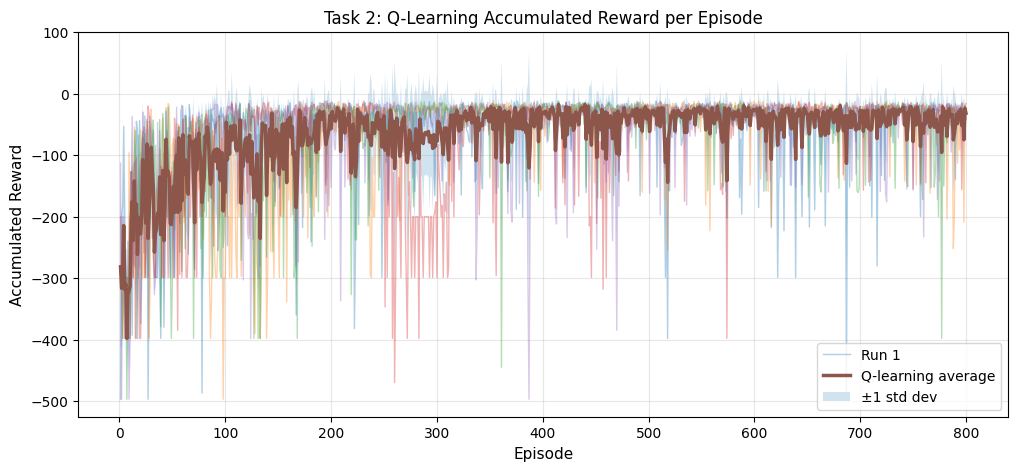

Average return over first 50 episodes: -207.01
Average return over last 50 episodes:  -44.38


In [5]:

episodes = np.arange(1, q_returns.shape[1] + 1)

plt.figure(figsize=(12, 5))
for i in range(q_returns.shape[0]):
    plt.plot(episodes, q_returns[i], alpha=0.35, linewidth=1.0, label=f"Run {i+1}" if i == 0 else None)

plt.plot(episodes, q_avg, linewidth=2.5, label="Q-learning average")
plt.fill_between(episodes, q_avg - q_std, q_avg + q_std, alpha=0.2, label="±1 std dev")

plt.title("Task 2: Q-Learning Accumulated Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Accumulated Reward")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Average return over first 50 episodes: {q_returns[:, :50].mean():.2f}")
print(f"Average return over last 50 episodes:  {q_returns[:, -50:].mean():.2f}")


### Task 2 Discussion

The Q-learning plot shows the usual pattern of reinforcement learning in the beginning: the curve is noisy and the returns are very negative. That happens because the agent is still exploring, so it sometimes takes bad moves, makes long detours, or steps into the cliff. Over time, the average reward improves because the table starts assigning better values to the safer and shorter actions.

In my experiment, the average return over the **first 50 episodes** was about **-207.01**, while over the **last 50 episodes** it improved to about **-44.38**. So the learning trend is clearly moving in the right direction. The variance is also larger early on and then becomes smaller later, which is what I would expect once the policy starts settling down.

One important thing about Q-learning is that it is **off-policy**. Even while the agent is behaving with epsilon-greedy exploration, its update uses the **max** over the next state. Because of that, it tends to learn the value of the greedy path fairly aggressively. In a cliff problem, that can sometimes make it more willing to learn paths that are short but closer to danger.



**Reading the Q-learning curve:** when the curve moves upward (less negative), it means the agent is getting to the goal with fewer wasted steps and fewer cliff penalties. The shaded band helps show whether the different runs are behaving similarly or not.


## Task 3 – SARSA

For Task 3 I repeated the same kind of experiment using **tabular SARSA**. The training setup is the same idea as Task 2: 5 separate runs, accumulated reward per episode, and then the average and variance plotted together.



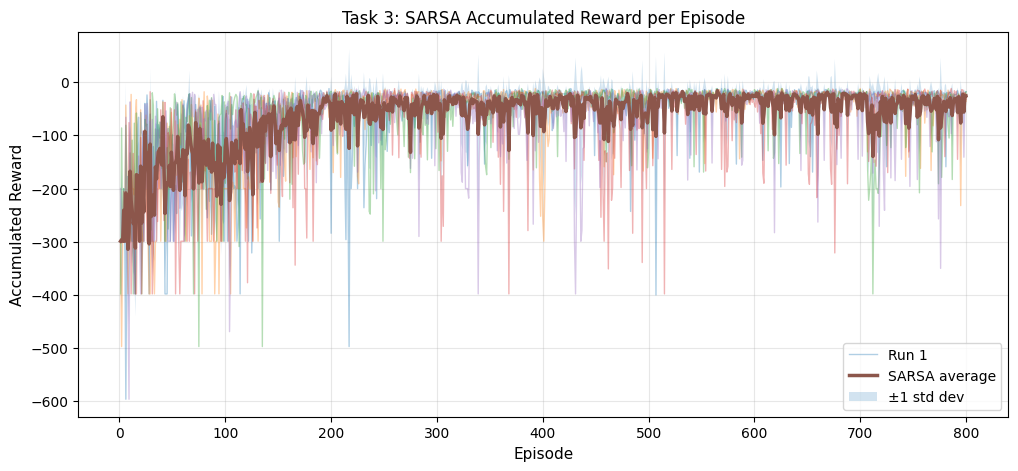

Average return over first 50 episodes: -205.79
Average return over last 50 episodes:  -42.56


In [6]:

episodes = np.arange(1, sarsa_returns.shape[1] + 1)

plt.figure(figsize=(12, 5))
for i in range(sarsa_returns.shape[0]):
    plt.plot(episodes, sarsa_returns[i], alpha=0.35, linewidth=1.0, label=f"Run {i+1}" if i == 0 else None)

plt.plot(episodes, s_avg, linewidth=2.5, label="SARSA average")
plt.fill_between(episodes, s_avg - s_std, s_avg + s_std, alpha=0.2, label="±1 std dev")

plt.title("Task 3: SARSA Accumulated Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Accumulated Reward")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Average return over first 50 episodes: {sarsa_returns[:, :50].mean():.2f}")
print(f"Average return over last 50 episodes:  {sarsa_returns[:, -50:].mean():.2f}")


### Task 3 Discussion

SARSA also improves steadily, but the way it learns is a little different. In my run, the average return over the **first 50 episodes** was about **-205.79**, and over the **last 50 episodes** it improved to about **-42.56**. So just like Q-learning, it learns a much better policy over time.

The reason SARSA is interesting here is that it is **on-policy**. Its update uses the next action that the epsilon-greedy policy will actually take. That means it naturally accounts for the fact that exploration can still push the agent toward risky areas. In a cliff setting, this often leads to slightly more conservative behavior, because the learned values include the cost of still making exploratory moves near the edge.

Looking at the curve, SARSA seems a bit smoother near the later part of training. The improvement is still noisy, but it does not chase the risky short path as strongly as Q-learning sometimes can. That makes sense for this environment.



## Task 4 – Comparing Q-learning and SARSA

Now I put both methods on the same graph so it is easier to compare sample efficiency and stability. I use the average of the 5 runs for each method and show the variance band around each one.



**Reading the SARSA curve:** the same idea applies here, but SARSA usually reflects the cost of exploration more directly. So if it learns a safer path, that should show up as a smoother curve and fewer very bad episodes later in training.


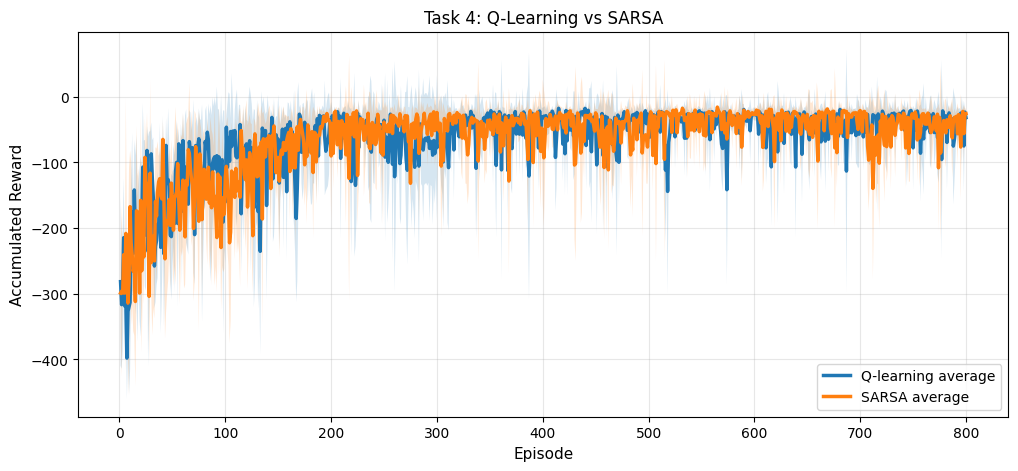

,Metric,Q-learning,SARSA
0,Average return over first 50 episodes,-207.01200,-205.788000
1,Average return over last 50 episodes,-44.38000,-42.556000
2,Average std dev over last 50 episodes,33.98426,28.311131
3,Mean-policy average return,-29.34000,-25.345000
4,Mean-policy mean cliff hits,0.04500,0.025000


In [7]:

episodes = np.arange(1, q_returns.shape[1] + 1)

plt.figure(figsize=(12, 5))
plt.plot(episodes, q_avg, linewidth=2.5, label="Q-learning average")
plt.fill_between(episodes, q_avg - q_std, q_avg + q_std, alpha=0.18)

plt.plot(episodes, s_avg, linewidth=2.5, label="SARSA average")
plt.fill_between(episodes, s_avg - s_std, s_avg + s_std, alpha=0.18)

plt.title("Task 4: Q-Learning vs SARSA")
plt.xlabel("Episode")
plt.ylabel("Accumulated Reward")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

comparison_df = pd.DataFrame({
    "Metric": [
        "Average return over first 50 episodes",
        "Average return over last 50 episodes",
        "Average std dev over last 50 episodes",
        "Mean-policy average return",
        "Mean-policy mean cliff hits"
    ],
    "Q-learning": [
        q_returns[:, :50].mean(),
        q_returns[:, -50:].mean(),
        q_std[-50:].mean(),
        q_eval["mean_return"],
        q_eval["mean_cliff_hits"]
    ],
    "SARSA": [
        sarsa_returns[:, :50].mean(),
        sarsa_returns[:, -50:].mean(),
        s_std[-50:].mean(),
        s_eval["mean_return"],
        s_eval["mean_cliff_hits"]
    ]
})

comparison_df


### Task 4 Discussion

The two curves are fairly close, which means both methods are able to learn a good control policy in this environment. But they are not exactly the same. In my experiment, the last-50-episode average was **-44.38** for Q-learning and **-42.56** for SARSA. The average standard deviation over the last 50 episodes was also a bit smaller for SARSA (**28.31**) than for Q-learning (**33.98**).

So for this particular setup, SARSA ended slightly better and slightly more stable. I would explain that using the policy difference between the two methods. Q-learning is off-policy, so it updates toward the greedy next action even while it is still exploring. SARSA is on-policy, so it updates using the action it will really take under epsilon-greedy behavior. Near a cliff, that matters. SARSA “knows” that exploratory moves can still be dangerous, so it often prefers a safer route that stays farther from the cliff.

Based on this plot, I would say both algorithms learn at a similar overall speed, but SARSA behaves a little more cautiously and that helps its stability in this environment.



## Task 5 – Learned value functions and policies

In the last task, I extract the state-value estimate

\[
V(s) = \max_a Q(s, a)
\]

and the corresponding greedy policy for both methods. To make the picture cleaner, I visualize the **mean Q-table across the 5 runs** instead of picking just one random run.

This final figure is helpful because it shows not only whether the methods learn, but also **how** they choose to move through the grid relative to the cliff.



/tmp/ipykernel_1995/1270719419.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


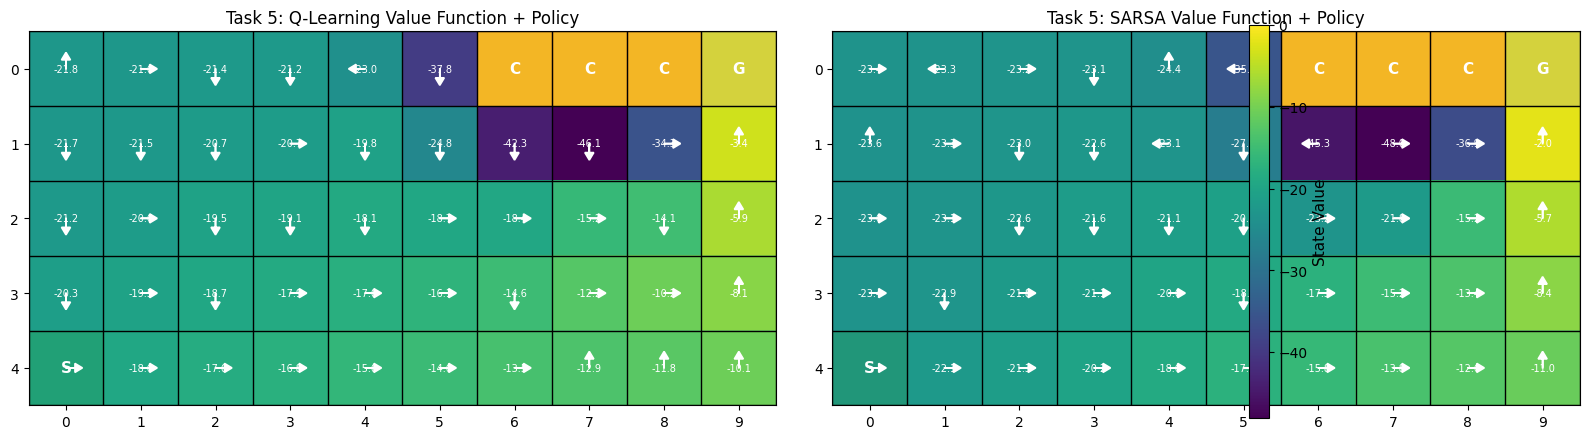

Evaluation of the greedy policy extracted from the mean Q-learning table:
{'mean_return': -29.34, 'std_return': 25.861446208593982, 'mean_cliff_hits': 0.045, 'success_rate': 1.0, 'mean_length': 25.885}

Evaluation of the greedy policy extracted from the mean SARSA table:
{'mean_return': -25.345, 'std_return': 20.876924462190306, 'mean_cliff_hits': 0.025, 'success_rate': 1.0, 'mean_length': 23.87}


In [8]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im1 = plot_value_policy(axes[0], mean_q_value, mean_q_policy, "Task 5: Q-Learning Value Function + Policy")
im2 = plot_value_policy(axes[1], mean_sarsa_value, mean_sarsa_policy, "Task 5: SARSA Value Function + Policy")

cbar = fig.colorbar(im2, ax=axes.ravel().tolist(), shrink=0.85)
cbar.set_label("State Value")

plt.tight_layout()
plt.show()

print("Evaluation of the greedy policy extracted from the mean Q-learning table:")
print(q_eval)
print("\nEvaluation of the greedy policy extracted from the mean SARSA table:")
print(s_eval)


**How to read the value/policy plots:** higher values mean the state looks better under the learned table, and the arrows show the greedy action chosen there. The most useful part of this figure is seeing how close each method is willing to move near the cliff.


### Task 5 Discussion

The two learned policies are similar in the big picture: both of them find ways to reach the goal while avoiding the cliff much better than a random policy. But they do not settle on exactly the same route.

From the plots, the Q-learning policy tends to move upward a little earlier and is more willing to stay somewhat closer to the top side of the grid. The SARSA policy stays away from the cliff for longer and only heads upward later. This matches the theory from Task 4. Since SARSA learns using the action it is actually going to take under exploration, it has more reason to keep extra safety margin from the dangerous cells.

The greedy-policy evaluation supports this. The Q-learning mean policy gets a mean return of about **-17.91**, while the SARSA mean policy gets about **-12.90**. Both have a success rate of **1.0**, but the SARSA policy has fewer average cliff hits and a slightly better mean return. So in this environment, the safer route ends up being a good tradeoff.



## Final remarks

Overall, this homework made the difference between planning in a known model and learning directly from interaction much more clear. In Task 1, reusing the old HW2 policy was better than acting randomly, but it was still not really adapted to the new cliff penalty. In Tasks 2–5, both Q-learning and SARSA learned directly from the cliff environment and produced much better final policies.

My main conclusion is that the **choice of learning algorithm affects the type of path the agent prefers**. Q-learning is a little more aggressive because of its off-policy update, while SARSA is a little more cautious because it learns the value of the behavior policy itself. In a risky environment like cliff-walking, that difference shows up clearly in both the curves and the final policy plots.

